In [33]:
import os
import rasterio
import numpy as np
from google.colab import drive
drive.mount('/content/drive')


dataset_path = '/content/drive/MyDrive/dataset'


tif_files = [f for f in os.listdir(dataset_path) if f.endswith('.tif')]
print("Fichiers trouvés :", tif_files)


images = {}
for filename in tif_files:
    name = filename.replace('.tif', '')
    filepath = os.path.join(dataset_path, filename)

    with rasterio.open(filepath) as src:
        images[name] = src.read()
        print(f"{name} → shape: {images[name].shape}, dtype: {images[name].dtype}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fichiers trouvés : ['S2_CA1.tif', 'S2_CA2.tif', 'CDL_CA1.tif', 'CDL_CA2.tif', 'CDL_AR2.tif', 'CDL_AR1.tif', 'S2_AR2.tif', 'S2_AR1.tif']
S2_CA1 → shape: (360, 929, 1114), dtype: float32
S2_CA2 → shape: (360, 929, 1115), dtype: float32
CDL_CA1 → shape: (1, 1131, 1076), dtype: uint8
CDL_CA2 → shape: (1, 1127, 1090), dtype: uint8
CDL_AR2 → shape: (1, 982, 962), dtype: uint8
CDL_AR1 → shape: (1, 975, 955), dtype: uint8
S2_AR2 → shape: (360, 929, 1114), dtype: float32
S2_AR1 → shape: (360, 929, 1115), dtype: float32


In [34]:
import numpy as np

cdl_classes = {
    "AR": {1: "Corn", 2: "Cotton", 5: "Soybeans", 3: "Rice"},
    "CA": {36: "Alfalfa", 75: "Almonds", 69: "Grapes", 204: "Pistachios", 3: "Rice"},
}

for state, cdl_map in cdl_classes.items():
    combined = np.concatenate([
        images[f"CDL_{state}1"][0].flatten(),
        images[f"CDL_{state}2"][0].flatten()
    ])
    valid = combined[combined != 0]
    total = len(valid)

    counts = {}
    for cdl_val, class_name in cdl_map.items():
        counts[class_name] = counts.get(class_name, 0) + (valid == cdl_val).sum()
    counts["Others"] = total - sum(counts.values())

    print(f"\nÉtat : {state}  |  Pixels valides : {total:,}")
    print(f"  {'Classe':<15} {'Pixels':>12} {'%':>8}")
    for class_name, count in counts.items():
        pct = count / total * 100
        note = "  ← autres cultures (<5%)" if class_name == "Others" else ""
        print(f"  {class_name:<15} {count:>12,} {pct:>7.2f}%{note}")


État : AR  |  Pixels valides : 1,701,061
  Classe                Pixels        %
  Corn                 132,977    7.82%
  Cotton                30,490    1.79%
  Soybeans             696,572   40.95%
  Rice                 197,101   11.59%
  Others               643,921   37.85%  ← autres cultures (<5%)

État : CA  |  Pixels valides : 1,626,903
  Classe                Pixels        %
  Alfalfa               22,483    1.38%
  Almonds              313,129   19.25%
  Grapes               227,155   13.96%
  Pistachios            63,119    3.88%
  Rice                 147,678    9.08%
  Others               853,339   52.45%  ← autres cultures (<5%)


In [35]:
from rasterio.warp import reproject, Resampling
import rasterio
import os

aligned_cdl = {}

pairs = [
    ("CDL_AR1", "S2_AR1"),
    ("CDL_AR2", "S2_AR2"),
    ("CDL_CA1", "S2_CA1"),
    ("CDL_CA2", "S2_CA2"),
]

for cdl_key, s2_key in pairs:
    cdl_path = os.path.join(dataset_path, cdl_key + ".tif")
    s2_path  = os.path.join(dataset_path, s2_key  + ".tif")

    with rasterio.open(cdl_path) as cdl_src, \
         rasterio.open(s2_path)  as s2_src:

        destination = np.zeros(
            (s2_src.height, s2_src.width),
            dtype=np.uint8
        )

        reproject(
            source=cdl_src.read(1),
            destination=destination,
            src_transform=cdl_src.transform,
            src_crs=cdl_src.crs,
            dst_transform=s2_src.transform,
            dst_crs=s2_src.crs,
            resampling=Resampling.nearest
        )

        aligned_cdl[cdl_key] = destination
        print(f"{cdl_key} aligné vers {s2_key} → shape: {destination.shape}")

CDL_AR1 aligné vers S2_AR1 → shape: (929, 1115)
CDL_AR2 aligné vers S2_AR2 → shape: (929, 1114)
CDL_CA1 aligné vers S2_CA1 → shape: (929, 1114)
CDL_CA2 aligné vers S2_CA2 → shape: (929, 1115)


In [36]:
TOTAL_SAMPLES = 10_000
np.random.seed(42)
all_samples = []

# Classes CDL exactes du papier
cdl_classes = {
    "AR": {5: "Soybeans", 3: "Rice", 1: "Corn", 2: "Cotton"},  # adapte les codes CDL réels
    "CA": {36: "Alfalfa", 75: "Almonds", 69: "Grapes", 204: "Pistachios", 3: "Rice"}
}

# Quantités exactes du papier (Table 2)
targets = {
    "AR": {"Soybeans": 4677, "Rice": 2423, "Corn": 1522, "Cotton": 762, "Others": 616},
    "CA": {"Grapes": 2054, "Rice": 2037, "Alfalfa": 974, "Almonds": 783, "Pistachios": 640, "Others": 3512}
}

for state, cdl_map in cdl_classes.items():
    s2_keys = sorted([k for k in images if k.startswith(f"S2_{state}")])
    cdl_keys = [f"CDL_{state}1", f"CDL_{state}2"]

    # ── 1. Construire le pool depuis aligned_cdl ──
    cdl_flat_list, tile_idx_list, pixel_idx_list = [], [], []
    for t_idx, cdl_key in enumerate(cdl_keys):
        flat = aligned_cdl[cdl_key].flatten()  # ← aligné !
        valid = flat != 0
        cdl_flat_list.append(flat[valid])
        tile_idx_list.append(np.full(valid.sum(), t_idx, dtype=np.int8))
        pixel_idx_list.append(np.where(valid)[0])

    cdl_all  = np.concatenate(cdl_flat_list)
    tile_all = np.concatenate(tile_idx_list)
    pidx_all = np.concatenate(pixel_idx_list)

    # ── 2. Indices par classe ──
    class_indices = {}
    known_mask = np.zeros(len(cdl_all), dtype=bool)
    for cdl_val, cls_name in cdl_map.items():
        idx = np.where(cdl_all == cdl_val)[0]
        class_indices[cls_name] = idx
        known_mask |= (cdl_all == cdl_val)
    class_indices["Others"] = np.where(~known_mask)[0]

    # ── 3. Tirage aléatoire selon quantités exactes du papier ──
    state_targets = targets[state]
    chosen_by_class = {}
    for cls_name, n in state_targets.items():
        idx = class_indices.get(cls_name, np.array([]))
        if len(idx) == 0:
            print(f"⚠️  {state} - {cls_name} : aucun pixel trouvé !")
            continue
        chosen_by_class[cls_name] = np.random.choice(
            idx, size=n, replace=n > len(idx)
        )
        print(f"{state} - {cls_name} : {len(idx):,} pixels dispo → {n} tirés")

    # ── 4. Extraction features S2 ──
    for cls_name, chosen in chosen_by_class.items():
        for t_idx, s2_key in enumerate(s2_keys):
            mask_t = tile_all[chosen] == t_idx
            if mask_t.sum() == 0:
                continue

            s2_arr  = images[s2_key]
            s2_flat = s2_arr.reshape(360, -1)
            pix     = np.clip(pidx_all[chosen[mask_t]], 0, s2_flat.shape[1] - 1)
            features = s2_flat[:, pix].T  # (n, 360)

            for i, feat in enumerate(features):
                feat_3d = feat.reshape(36, 10)
                all_samples.append({
                    "state": state,
                    "class": cls_name,
                    **{f"T{t}_B{b}": float(feat_3d[t, b])
                       for t in range(36) for b in range(10)}
                })

# ── Sauvegarde ──
import pandas as pd
from collections import Counter

df = pd.DataFrame(all_samples)
band_cols = [c for c in df.columns if c.startswith("T")]

for state, name in [("AR", "arkansas"), ("CA", "california")]:
    df_s = df[df["state"] == state]
    X = df_s[band_cols].values.reshape(len(df_s), 36, 10)
    y = df_s["class"].values
    np.save(f'/content/drive/MyDrive/dataset/pixels_{name}.npy', X)
    np.save(f'/content/drive/MyDrive/dataset/labels_{name}.npy', y)
    print(f"\n{name} → X:{X.shape}")
    print("Distribution :", Counter(y))

AR - Soybeans : 847,260 pixels dispo → 4677 tirés
AR - Rice : 239,764 pixels dispo → 2423 tirés
AR - Corn : 161,677 pixels dispo → 1522 tirés
AR - Cotton : 37,057 pixels dispo → 762 tirés
AR - Others : 783,407 pixels dispo → 616 tirés
CA - Grapes : 284,663 pixels dispo → 2054 tirés
CA - Rice : 190,835 pixels dispo → 2037 tirés
CA - Alfalfa : 28,621 pixels dispo → 974 tirés
CA - Almonds : 394,114 pixels dispo → 783 tirés
CA - Pistachios : 79,010 pixels dispo → 640 tirés
CA - Others : 1,092,089 pixels dispo → 3512 tirés

arkansas → X:(10000, 36, 10)
Distribution : Counter({'Soybeans': 4677, 'Rice': 2423, 'Corn': 1522, 'Cotton': 762, 'Others': 616})

california → X:(10000, 36, 10)
Distribution : Counter({'Others': 3512, 'Grapes': 2054, 'Rice': 2037, 'Alfalfa': 974, 'Almonds': 783, 'Pistachios': 640})


In [39]:
BATCH_SIZE   = 32
EPOCHS       = 200
LR           = 0.001
WEIGHT_DECAY = 1e-4
N_HEADS      = 5
FF_FACTOR    = 8
DROPOUT      = 0.4
TRAIN_N      = 240
VAL_N        = 60

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import math
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")



class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=36):
        super().__init__()
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self):
        return self.pe


class ECAModule(nn.Module):
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.conv     = nn.Conv1d(1, 1, kernel_size=kernel_size,
                                  padding=kernel_size // 2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = y.transpose(-1, -2)
        y = self.conv(y)
        y = y.transpose(-1, -2)
        y = self.sigmoid(y)
        return x * y


class ALPEModule(nn.Module):
    def __init__(self, d_model, max_len=36):
        super().__init__()
        self.conv = nn.Conv1d(d_model, d_model,
                              kernel_size=3, padding=1, bias=False)
        self.eca  = ECAModule(d_model)
        self.pe   = PositionalEncoding(d_model, max_len)

    def forward(self, mask):
        pe   = self.pe().unsqueeze(0)
        mask = mask.unsqueeze(-1)
        pe   = pe * mask
        pe   = pe.transpose(1, 2)
        pe   = self.conv(pe)
        pe   = self.eca(pe)
        return pe.transpose(1, 2)


class CNNSubModule(nn.Module):
    def __init__(self, d_model, kernel_size=3, dropout=0.2):
        super().__init__()
        pad          = kernel_size // 2
        self.conv1   = nn.Conv1d(d_model, d_model, kernel_size,
                                 padding=pad, bias=False)
        self.norm1   = nn.BatchNorm1d(d_model)
        self.conv2   = nn.Conv1d(d_model, d_model, kernel_size,
                                 padding=pad, bias=False)
        self.norm2   = nn.BatchNorm1d(d_model)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x):
        x   = x.transpose(1, 2)
        res = x
        out = self.relu(self.norm1(self.conv1(x)))
        out = self.dropout(out)
        out = self.norm2(self.conv2(out))
        out = self.relu(out + res)
        return out.transpose(1, 2)


class TransformerSubModule(nn.Module):
    def __init__(self, d_model, n_heads=5, use_alpe=False,
                 max_len=36, ff_factor=8, dropout=0.2):
        super().__init__()
        self.use_alpe = use_alpe

        if use_alpe:
            self.pe = ALPEModule(d_model, max_len)
        else:
            self.pe = PositionalEncoding(d_model, max_len)

        self.attention = nn.MultiheadAttention(
            d_model, n_heads, batch_first=True, dropout=dropout
        )
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.ff      = nn.Sequential(
            nn.Linear(d_model, d_model * ff_factor),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(d_model * ff_factor, d_model)
        )
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x, mask=None):
        if self.use_alpe:
            pe = self.pe(mask)
        else:
            pe = self.pe().unsqueeze(0)

        x           = x + pe
        attn_out, _ = self.attention(x, x, x)
        x           = self.norm1(x + self.dropout(attn_out))
        x           = self.norm2(x + self.dropout(self.ff(x)))
        return x


class CTFusionModule(nn.Module):
    def __init__(self, d_model, n_heads=5, kernel_size=3,
                 use_alpe=False, max_len=36, ff_factor=8, dropout=0.2):
        super().__init__()
        self.cnn         = CNNSubModule(d_model, kernel_size, dropout)
        self.transformer = TransformerSubModule(
            d_model, n_heads, use_alpe, max_len, ff_factor, dropout
        )

    def forward(self, x, mask=None):
        cnn_out   = self.cnn(x)
        trans_out = self.transformer(x, mask)
        return torch.cat([cnn_out, trans_out], dim=-1)


class MCTNet(nn.Module):
    def __init__(self, num_classes, n_bands=10, n_steps=36,
                 n_heads=5, ff_factor=8, dropout=0.2):
        super().__init__()

        self.stage1 = CTFusionModule(
            d_model=n_bands, n_heads=n_heads, use_alpe=True,
            max_len=n_steps, ff_factor=ff_factor, dropout=dropout
        )
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.stage2 = CTFusionModule(
            d_model=n_bands * 2, n_heads=n_heads, use_alpe=False,
            max_len=n_steps // 2, ff_factor=ff_factor, dropout=dropout
        )
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        self.stage3 = CTFusionModule(
            d_model=n_bands * 4, n_heads=n_heads, use_alpe=False,
            max_len=n_steps // 4, ff_factor=ff_factor, dropout=dropout
        )

        self.global_pool = nn.AdaptiveMaxPool1d(1)
        self.dropout_out = nn.Dropout(p=dropout)
        self.mlp         = nn.Linear(n_bands * 8, num_classes)

    def forward(self, x, mask):
        if x.shape[2] != 10:
            x = x.transpose(1, 2)

        x = self.stage1(x, mask)
        x = x.transpose(1, 2)
        x = self.pool1(x)
        x = x.transpose(1, 2)

        x = self.stage2(x)
        x = x.transpose(1, 2)
        x = self.pool2(x)
        x = x.transpose(1, 2)

        x = self.stage3(x)
        x = x.transpose(1, 2)
        x = self.global_pool(x).squeeze(-1)
        x = self.dropout_out(x)
        return self.mlp(x)
class CropDataset(Dataset):
    def __init__(self, pixels, mask, labels_enc):
        self.X    = torch.tensor(pixels / 10000.0, dtype=torch.float32)
        self.mask = torch.tensor(mask,             dtype=torch.float32)
        self.y    = torch.tensor(labels_enc,       dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.mask[i], self.y[i]


def preparer_splits(labels_enc, train_n=240, val_n=60, seed=42):
    np.random.seed(seed)
    classes = np.unique(labels_enc)
    idx_tr, idx_val, idx_te = [], [], []
    for c in classes:
        idx_c = np.where(labels_enc == c)[0]
        np.random.shuffle(idx_c)
        tr = min(train_n, len(idx_c))
        v  = min(val_n,   len(idx_c) - tr)
        idx_tr .extend(idx_c[:tr])
        idx_val.extend(idx_c[tr:tr + v])
        idx_te .extend(idx_c[tr + v:])
    return np.array(idx_tr), np.array(idx_val), np.array(idx_te)

print("Modules MCTNet définis !")

Device : cuda
Modules MCTNet définis !


In [41]:
class CropDataset(Dataset):
    def __init__(self, pixels, mask, labels_enc):
        self.X    = torch.tensor(pixels / 10000.0, dtype=torch.float32)
        self.mask = torch.tensor(mask,             dtype=torch.float32)
        self.y    = torch.tensor(labels_enc,       dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.mask[i], self.y[i]


def preparer_splits(labels_enc, train_n=240, val_n=60, seed=42):
    np.random.seed(seed)
    classes = np.unique(labels_enc)
    idx_tr, idx_val, idx_te = [], [], []
    for c in classes:
        idx_c = np.where(labels_enc == c)[0]
        np.random.shuffle(idx_c)
        tr = min(train_n, len(idx_c))
        v  = min(val_n,   len(idx_c) - tr)
        idx_tr .extend(idx_c[:tr])
        idx_val.extend(idx_c[tr:tr + v])
        idx_te .extend(idx_c[tr + v:])
    return np.array(idx_tr), np.array(idx_val), np.array(idx_te)

print("Modules MCTNet définis !")

Modules MCTNet définis !


In [42]:
def entrainer(pixels, labels, zone_nom, classes,
              n_heads=N_HEADS, ff_factor=FF_FACTOR, dropout=DROPOUT,
              n_epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR):

    print(f"\n{'='*55}")
    print(f"  ENTRAÎNEMENT — {zone_nom}")
    print(f"{'='*55}")

    classes_presentes = [c for c in classes if c in np.unique(labels)]
    le         = LabelEncoder()
    le.fit(classes_presentes)
    n_classes  = len(classes_presentes)
    labels_enc = le.transform(labels)
    print(f"  Classes : {classes_presentes}")

    mask   = (~np.all(pixels == 0, axis=2)).astype(np.float32)
    idx_tr, idx_val, idx_te = preparer_splits(labels_enc, TRAIN_N, VAL_N)
    print(f"  Train={len(idx_tr)} | Val={len(idx_val)} | Test={len(idx_te)}")

    tr_dl  = DataLoader(CropDataset(pixels[idx_tr],  mask[idx_tr],  labels_enc[idx_tr]),
                        batch_size=batch_size, shuffle=True, pin_memory=True)
    val_dl = DataLoader(CropDataset(pixels[idx_val], mask[idx_val], labels_enc[idx_val]),
                        batch_size=64, pin_memory=True)
    te_dl  = DataLoader(CropDataset(pixels[idx_te],  mask[idx_te],  labels_enc[idx_te]),
                        batch_size=64, pin_memory=True)


    model = MCTNet(
        num_classes=n_classes,
        n_bands=pixels.shape[2],
        n_steps=pixels.shape[1],
        n_heads=n_heads,
        ff_factor=ff_factor,
        dropout=dropout
    ).to(device)

    opt       = optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    crit      = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max',
                                                     factor=0.5, patience=20)

    print(f"  Paramètres : {sum(p.numel() for p in model.parameters()):,}")

    best_val_acc = 0.0
    best_state   = None
    history      = {'train_loss': [], 'val_acc': [], 'val_loss': []}

    for epoch in range(1, n_epochs + 1):
        model.train()
        running_loss = 0.0
        for x, m, y in tr_dl:
            x, m, y = x.to(device), m.to(device), y.to(device)
            opt.zero_grad()
            loss = crit(model(x, m), y)
            loss.backward()
            opt.step()
            running_loss += loss.item() * len(y)
        train_loss = running_loss / len(tr_dl.dataset)

        model.eval()
        preds_v, trues_v = [], []
        val_loss_total   = 0.0
        with torch.no_grad():
            for x, m, y in val_dl:
                x, m, y = x.to(device), m.to(device), y.to(device)
                out = model(x, m)
                val_loss_total += crit(out, y).item() * len(y)
                preds_v.extend(out.argmax(1).cpu().numpy())
                trues_v.extend(y.cpu().numpy())
        val_acc  = accuracy_score(trues_v, preds_v)
        val_loss = val_loss_total / len(val_dl.dataset)
        scheduler.step(val_acc)

        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc)
        history['val_loss'].append(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 20 == 0:
            print(f"  Epoch {epoch:>3}/{n_epochs} | Train Loss={train_loss:.4f} "
                  f"| Val Loss={val_loss:.4f} | Best={best_val_acc:.4f}")

    model.load_state_dict(best_state)
    model.eval()
    preds_te, trues_te = [], []
    with torch.no_grad():
        for x, m, y in te_dl:
            x, m = x.to(device), m.to(device)
            preds_te.extend(model(x, m).argmax(1).cpu().numpy())
            trues_te.extend(y.numpy())

    oa    = accuracy_score(trues_te, preds_te)
    kappa = cohen_kappa_score(trues_te, preds_te)
    f1    = f1_score(trues_te, preds_te, average='macro', zero_division=0)

    ref_oa    = '0.968' if 'Arkansas'   in zone_nom else '0.852'
    ref_kappa = '0.951' if 'Arkansas'   in zone_nom else '0.806'
    ref_f1    = '0.933' if 'Arkansas'   in zone_nom else '0.829'
    print(f"\n  ── Résultats {zone_nom} ──────────────────")
    print(f"  {'Métrique':<8} {'Notre':>8} {'Article':>8}")
    print(f"  {'-'*26}")
    print(f"  {'OA':<8} {oa:>8.3f} {ref_oa:>8}")
    print(f"  {'Kappa':<8} {kappa:>8.3f} {ref_kappa:>8}")
    print(f"  {'F1':<8} {f1:>8.3f} {ref_f1:>8}")

    torch.save(
        {'model_state_dict': best_state, 'classes': classes_presentes,
         'oa': oa, 'kappa': kappa, 'f1': f1},
        dossier + f'/mctnet_{zone_nom.lower()}.pth'
    )
    print(f"  Modèle sauvegardé")

    return oa, kappa, f1, best_state, le, trues_te, preds_te, history

In [43]:
import pandas as pd
from collections import Counter

df = pd.DataFrame(all_samples)
band_cols = [c for c in df.columns if c.startswith("T")]

for state, name in [("AR", "arkansas"), ("CA", "california")]:
    df_s = df[df["state"] == state]
    X = df_s[band_cols].values.reshape(len(df_s), 36, 10)
    y = df_s["class"].values
    np.save(f'/content/drive/MyDrive/dataset/pixels_{name}.npy', X)
    np.save(f'/content/drive/MyDrive/dataset/labels_{name}.npy', y)
    print(f"\n{name} → X:{X.shape}")
    print("Distribution :", Counter(y))

dossier      = '/content/drive/MyDrive/dataset'
pixels_ar    = np.load(dossier + '/pixels_arkansas.npy')
labels_ar    = np.load(dossier + '/labels_arkansas.npy',  allow_pickle=True)
pixels_cal   = np.load(dossier + '/pixels_california.npy')
labels_cal   = np.load(dossier + '/labels_california.npy', allow_pickle=True)

print(f"\nArkansas   : {pixels_ar.shape}")
print(f"California : {pixels_cal.shape}")
print("Arkansas   :", Counter(labels_ar))
print("California :", Counter(labels_cal))


arkansas → X:(10000, 36, 10)
Distribution : Counter({'Soybeans': 4677, 'Rice': 2423, 'Corn': 1522, 'Cotton': 762, 'Others': 616})

california → X:(10000, 36, 10)
Distribution : Counter({'Others': 3512, 'Grapes': 2054, 'Rice': 2037, 'Alfalfa': 974, 'Almonds': 783, 'Pistachios': 640})

Arkansas   : (10000, 36, 10)
California : (10000, 36, 10)
Arkansas   : Counter({'Soybeans': 4677, 'Rice': 2423, 'Corn': 1522, 'Cotton': 762, 'Others': 616})
California : Counter({'Others': 3512, 'Grapes': 2054, 'Rice': 2037, 'Alfalfa': 974, 'Almonds': 783, 'Pistachios': 640})


In [46]:

classes_ar  = ['Soybeans', 'Rice', 'Corn', 'Cotton', 'Others']
classes_cal = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']

oa_ar,  k_ar,  f1_ar,  state_ar,  le_ar,  trues_ar,  preds_ar,  hist_ar  = entrainer(
    pixels_ar,  labels_ar,  "Arkansas",   classes_ar
)
oa_cal, k_cal, f1_cal, state_cal, le_cal, trues_cal, preds_cal, hist_cal = entrainer(
    pixels_cal, labels_cal, "California", classes_cal
)


  ENTRAÎNEMENT — Arkansas
  Classes : ['Soybeans', 'Rice', 'Corn', 'Cotton', 'Others']
  Train=1200 | Val=300 | Test=8500
  Paramètres : 56,778
  Epoch  20/200 | Train Loss=0.4660 | Val Loss=0.4907 | Best=0.8600
  Epoch  40/200 | Train Loss=0.3645 | Val Loss=0.4486 | Best=0.8733
  Epoch  60/200 | Train Loss=0.3482 | Val Loss=0.4481 | Best=0.8833
  Epoch  80/200 | Train Loss=0.2635 | Val Loss=0.4471 | Best=0.8833
  Epoch 100/200 | Train Loss=0.2388 | Val Loss=0.4410 | Best=0.8833
  Epoch 120/200 | Train Loss=0.2303 | Val Loss=0.4230 | Best=0.8867
  Epoch 140/200 | Train Loss=0.1939 | Val Loss=0.4450 | Best=0.8867
  Epoch 160/200 | Train Loss=0.1831 | Val Loss=0.4463 | Best=0.8867
  Epoch 180/200 | Train Loss=0.1879 | Val Loss=0.4442 | Best=0.8867
  Epoch 200/200 | Train Loss=0.1885 | Val Loss=0.4498 | Best=0.8867

  ── Résultats Arkansas ──────────────────
  Métrique    Notre  Article
  --------------------------
  OA          0.861    0.968
  Kappa       0.798    0.951
  F1          0

In [47]:
# ====================== AFFICHAGE RÉSULTATS ======================

print("\n================= RÉSULTATS =================\n")
print("🔹 Arkansas")
print("Papier     → OA=0.968 | Kappa=0.951 | F1=0.933")
print(f"Ton modèle → OA={oa_ar:.3f} | Kappa={k_ar:.3f} | F1={f1_ar:.3f}")
print("\n--------------------------------------------\n")
print("🔹 California")
print("Papier     → OA=0.852 | Kappa=0.806 | F1=0.829")
print(f"Ton modèle → OA={oa_cal:.3f} | Kappa={k_cal:.3f} | F1={f1_cal:.3f}")
print("\n============================================\n")


================= RÉSULTATS =================

🔹 Arkansas
Papier     → OA=0.968 | Kappa=0.951 | F1=0.933
Ton modèle → OA=0.861 | Kappa=0.798 | F1=0.790

--------------------------------------------

🔹 California
Papier     → OA=0.852 | Kappa=0.806 | F1=0.829
Ton modèle → OA=0.780 | Kappa=0.717 | F1=0.727




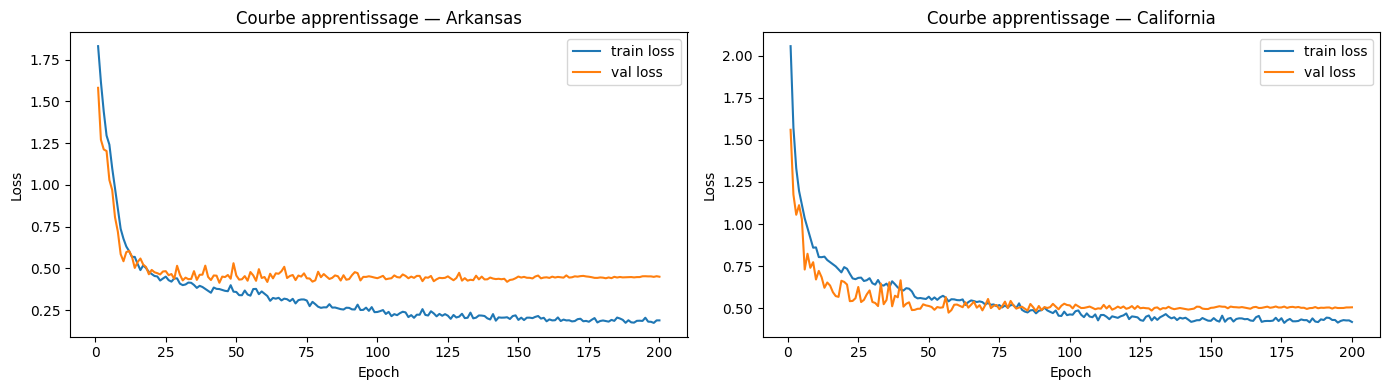

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, hist, nom in zip(axes, [hist_ar, hist_cal], ['Arkansas', 'California']):
    epochs = range(1, len(hist['train_loss']) + 1)
    ax.plot(epochs, hist['train_loss'], label='train loss')
    ax.plot(epochs, hist['val_loss'],   label='val loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'Courbe apprentissage — {nom}')
    ax.legend()
plt.tight_layout()
plt.show()

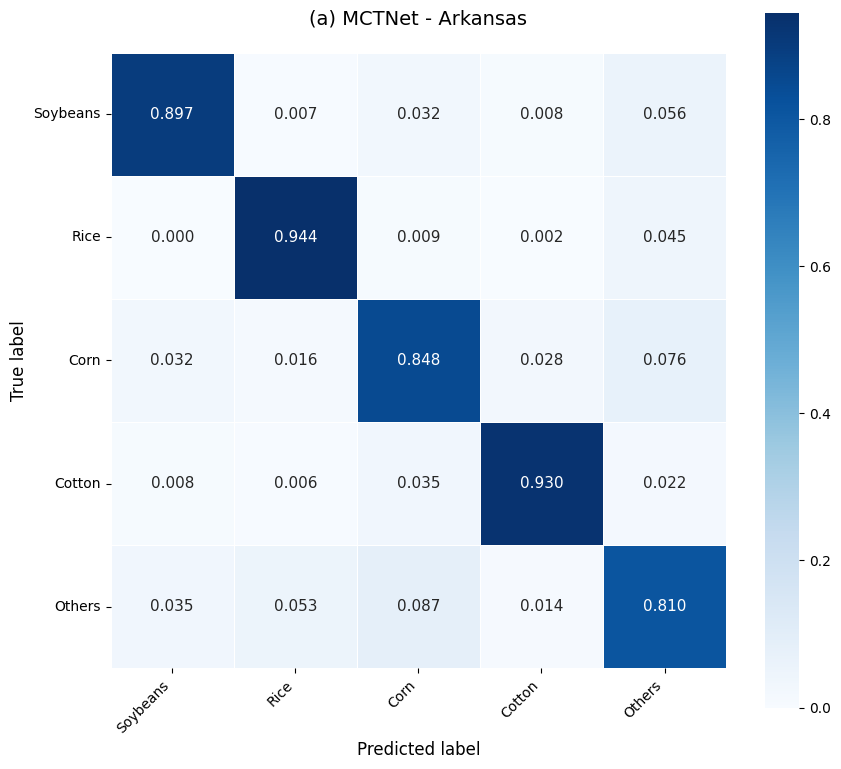

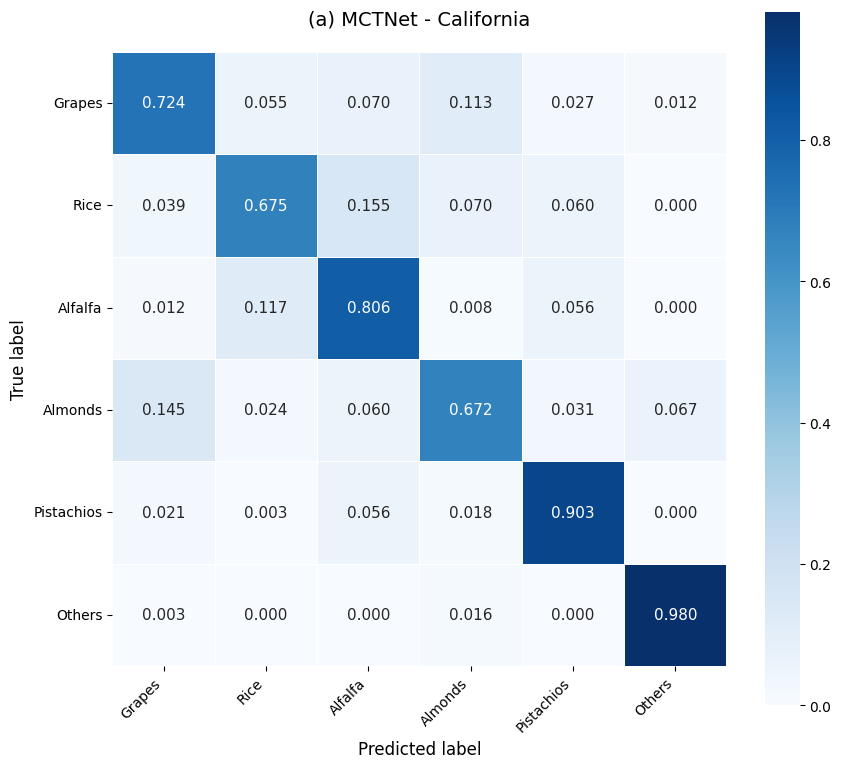

In [48]:
def plot_confusion_matrix(y_true, y_pred, classes, zone_name, normalize=True):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(9, 8))
    sns.heatmap(cm, annot=True, fmt='.3f' if normalize else 'd',
                cmap='Blues', cbar=True, square=True,
                xticklabels=classes, yticklabels=classes,
                linewidths=0.5, linecolor='white', annot_kws={"size": 11})
    plt.title(f'(a) MCTNet - {zone_name}', fontsize=14, pad=20)
    plt.xlabel('Predicted label', fontsize=12)
    plt.ylabel('True label',      fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(trues_ar,  preds_ar,  classes_ar,  "Arkansas")
plot_confusion_matrix(trues_cal, preds_cal, classes_cal, "California")